# Exploratory Visualizations for Student Performance

**Prepared by: Min Khant Kyaw (6845034)**  
**Role: Student C — Visualization Specialist**

This notebook uses the cleaned student-performance dataset to examine distributions, group differences in final grades, rank-based relationships, normality, and interactive patterns.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from IPython.display import display

project_root = Path("/Users/minkhantkyaw/Documents/Statistics-superstars")

data_path = project_root / "data" / "processed" / "cleaned_data.csv"
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 1. Distribution plots

Histograms with KDE curves are used only for continuous or near-continuous variables. Coded ordinal variables are shown as count plots so their discrete categories are not mistaken for continuous values.

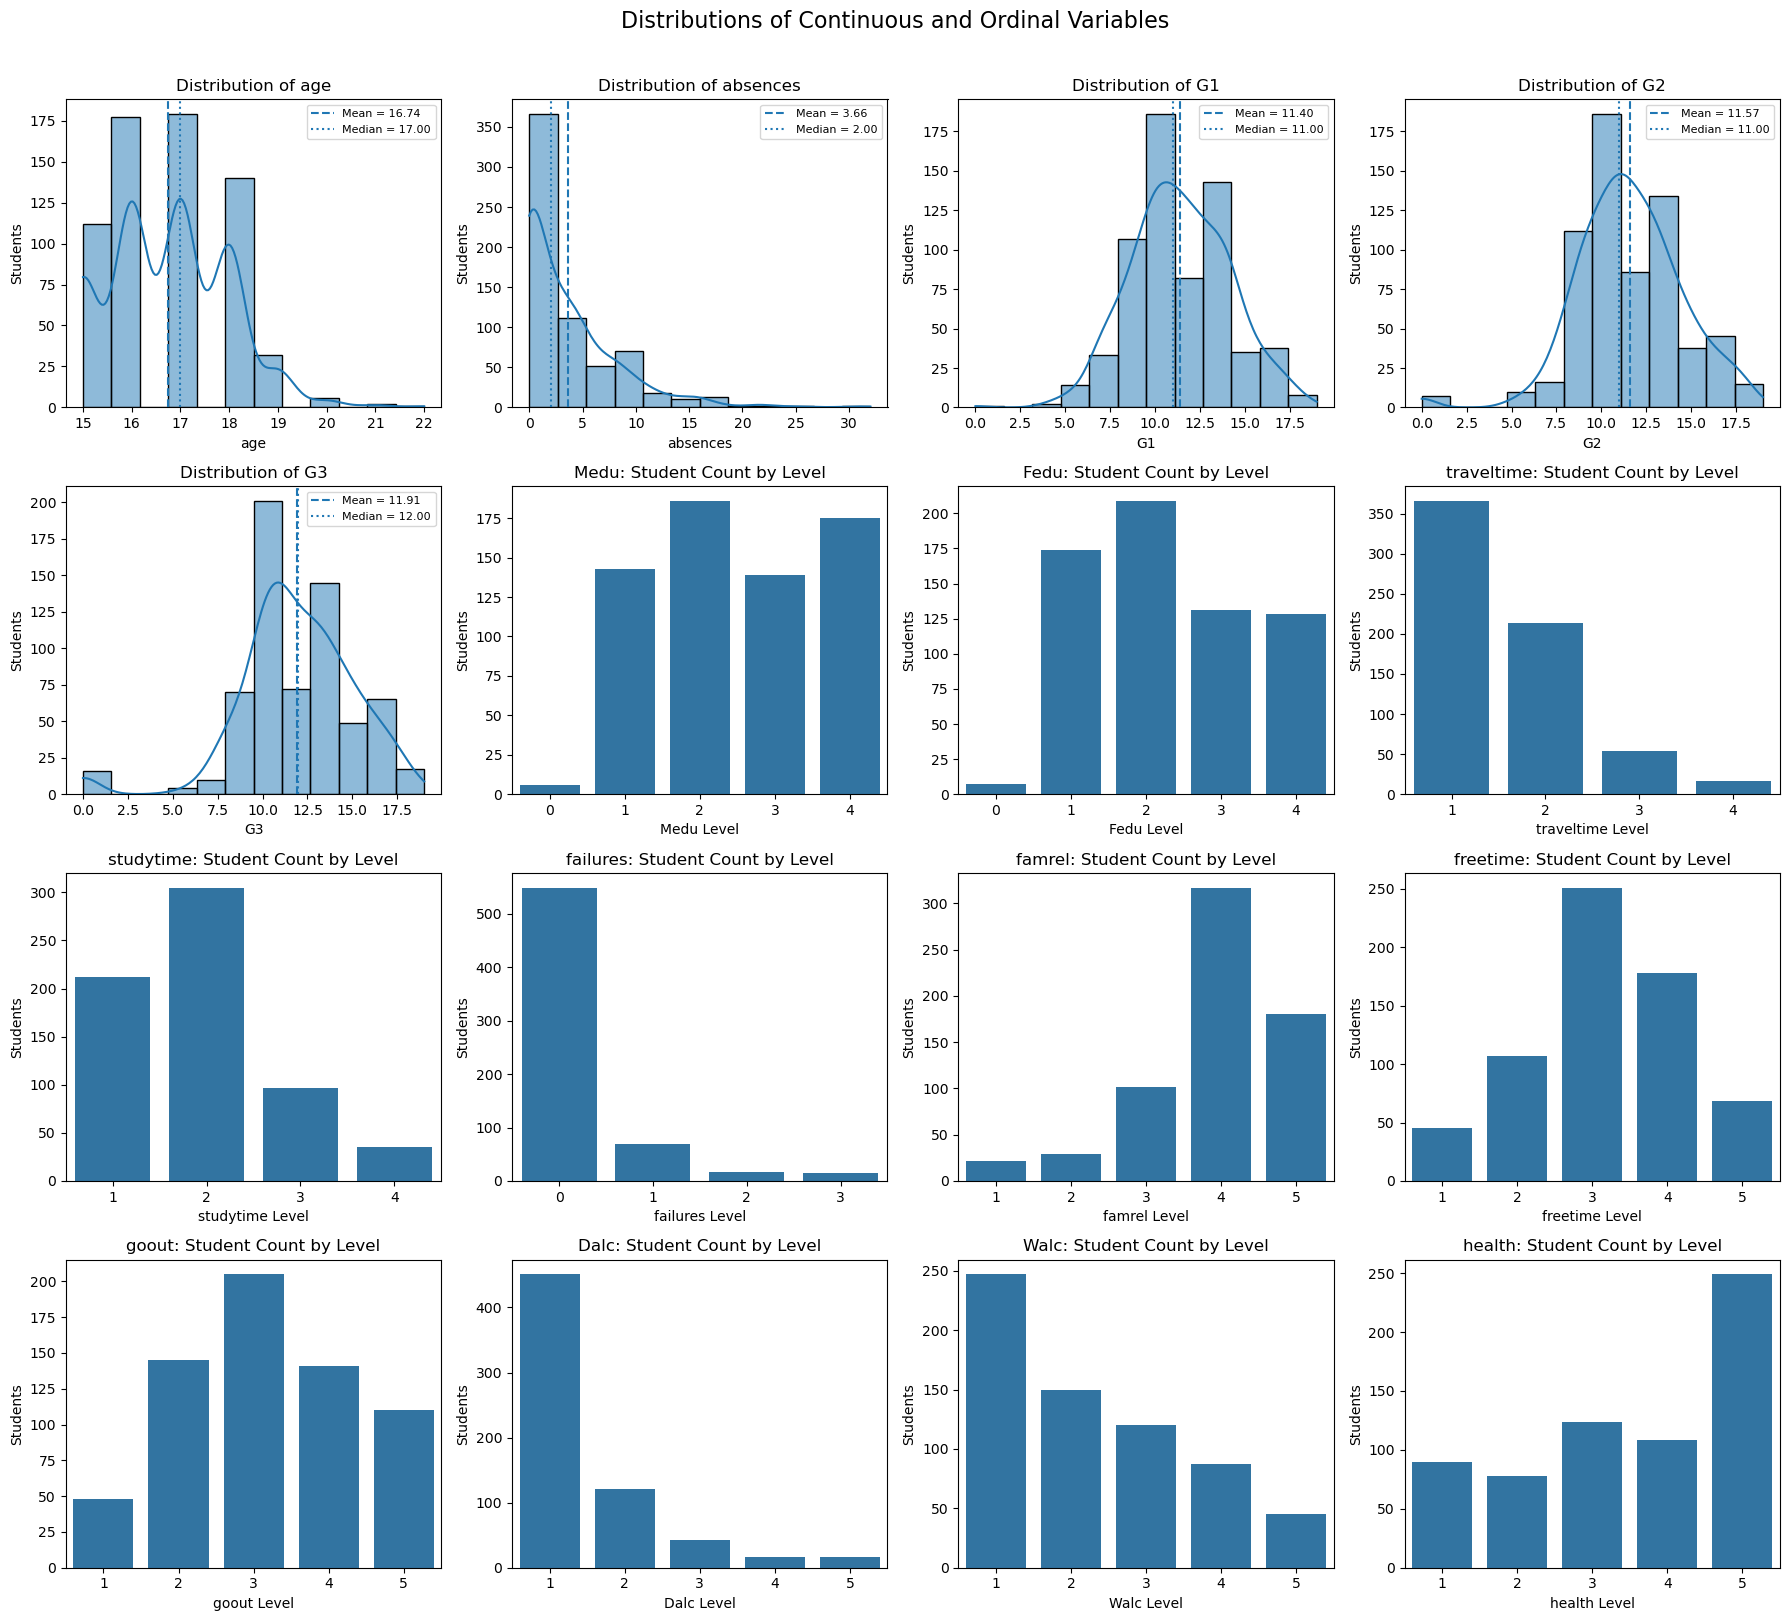

Saved: reports/figures/distribution_plots.png


In [2]:
continuous_cols = ['age', 'absences', 'G1', 'G2', 'G3']

ordinal_cols = [
    'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
    'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health'
]

# Continuous variables: histograms with KDE
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    values = df[col].dropna()

    sns.histplot(
        values,
        kde=True,
        ax=ax,
        bins=12
    )

    ax.axvline(
        values.mean(),
        linestyle='--',
        label=f"Mean = {values.mean():.2f}"
    )

    ax.axvline(
        values.median(),
        linestyle=':',
        label=f"Median = {values.median():.2f}"
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Students")
    ax.legend(fontsize=8)

# Ordinal variables: count plots
for ax, col in zip(axes[len(continuous_cols):], ordinal_cols):
    order = sorted(df[col].dropna().unique())

    sns.countplot(
        data=df,
        x=col,
        order=order,
        ax=ax
    )

    ax.set_title(f"{col}: Student Count by Level")
    ax.set_xlabel(f"{col} Level")
    ax.set_ylabel("Students")

    # Make ordinal categories clearly discrete
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([str(int(x)) if float(x).is_integer() else str(x)
                        for x in order])

# Hide unused panels
for ax in axes[len(continuous_cols) + len(ordinal_cols):]:
    ax.set_visible(False)

fig.suptitle(
    "Distributions of Continuous and Ordinal Variables",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    figures_dir / "distribution_plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: reports/figures/distribution_plots.png")

**Findings.** Final grade `G3` is centered around 12 (median = 12), while absences are right-skewed: most students have few absences, but a smaller group has many. The count plots show that ordinal responses are concentrated in a few categories, so treating these codes as continuous measurements would be misleading.

## 2. Final-grade comparisons across student groups

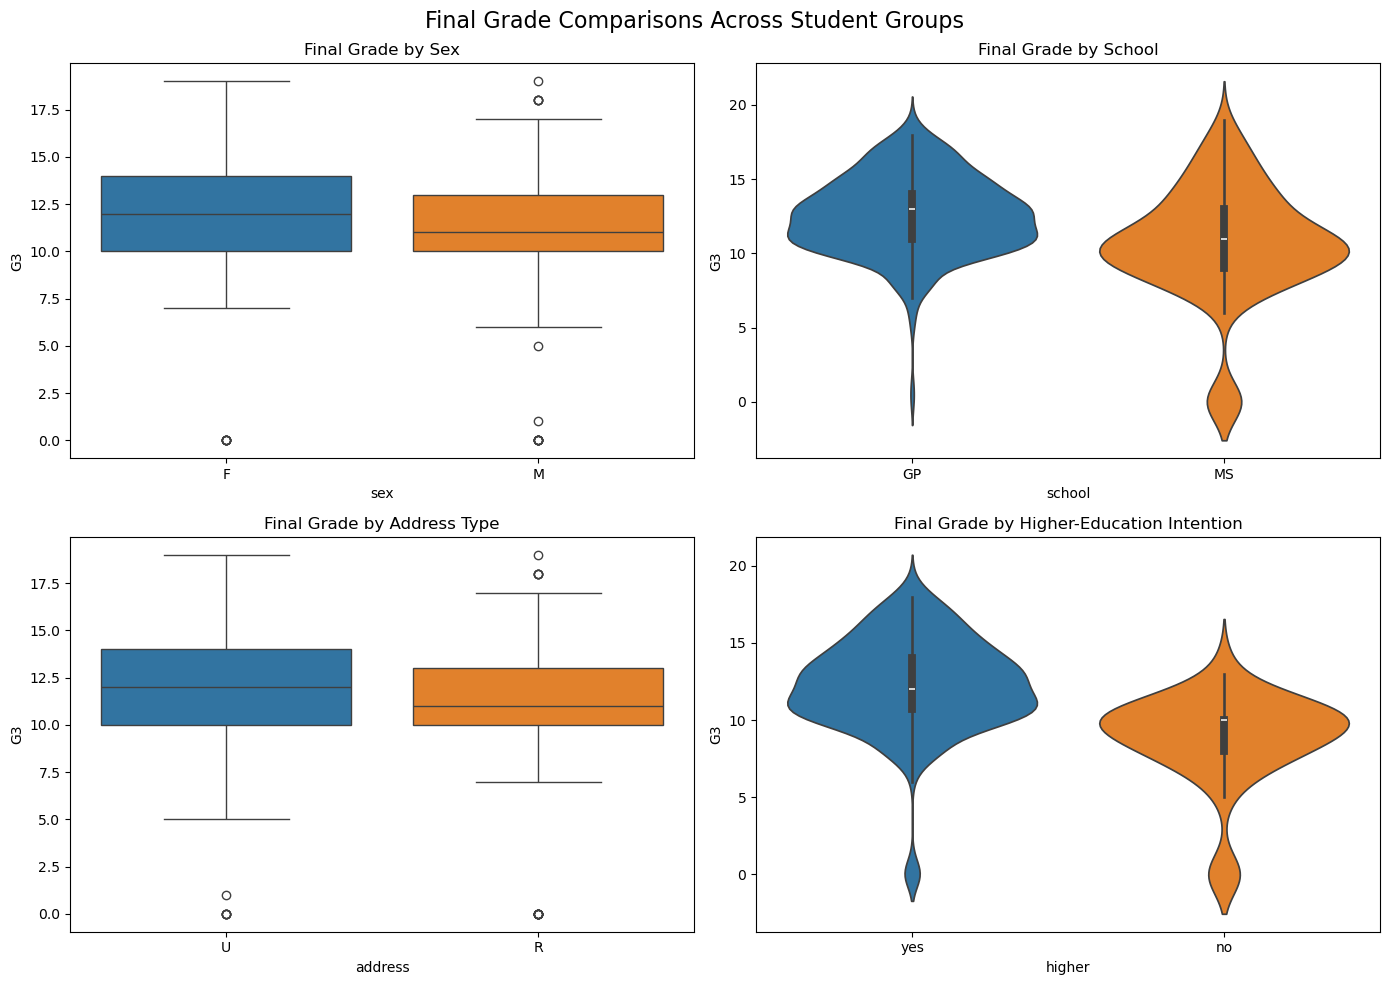

Saved: reports/figures/boxplots.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='sex', y='G3', hue='sex', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Final Grade by Sex')

sns.violinplot(data=df, x='school', y='G3', hue='school', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Final Grade by School')

sns.boxplot(data=df, x='address', y='G3', hue='address', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Final Grade by Address Type')

sns.violinplot(data=df, x='higher', y='G3', hue='higher', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Final Grade by Higher-Education Intention')

fig.suptitle('Final Grade Comparisons Across Student Groups', fontsize=16)
plt.tight_layout()
plt.savefig(figures_dir / 'boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/boxplots.png')

**Findings.** Students at GP have a higher median final grade (13) than students at MS (11). Students intending to pursue higher education also have a higher median grade (12) than those who do not (10). These are descriptive group differences; the plots alone do not establish causation.

## 3. Spearman correlation heatmap

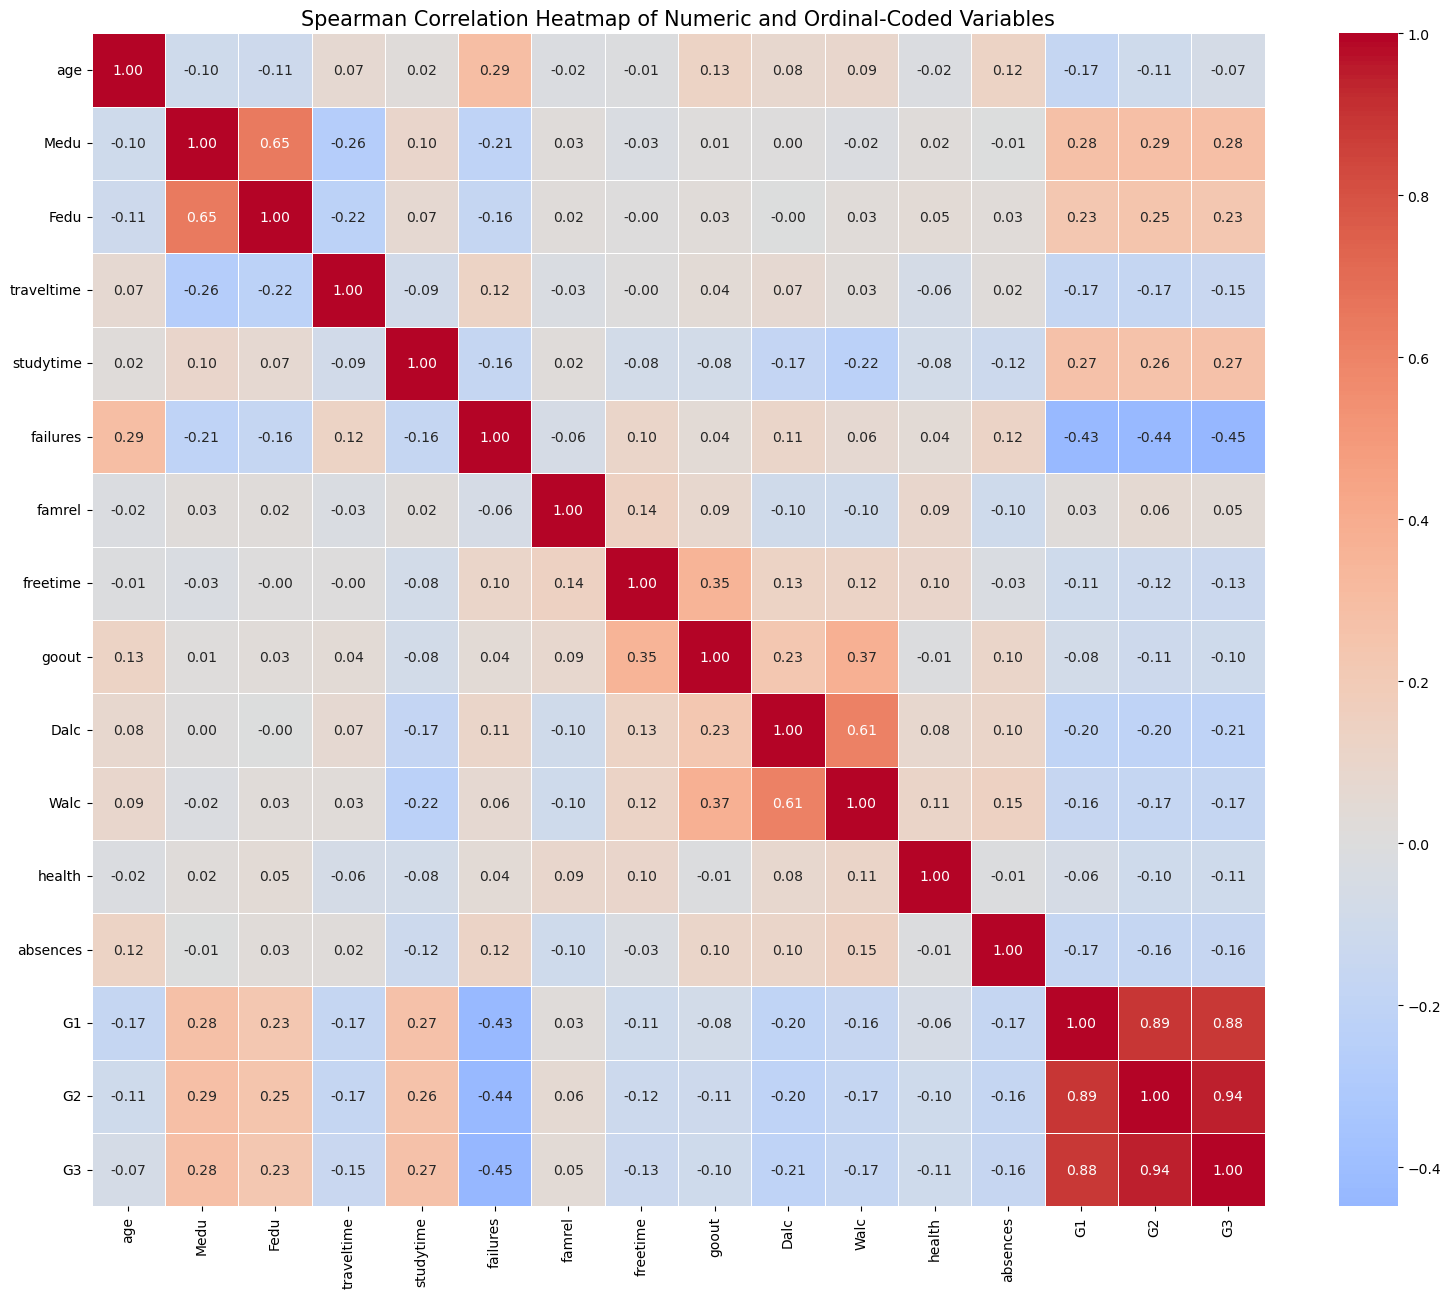

Saved: reports/figures/correlation_heatmap.png


In [4]:
spearman_matrix = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(16, 13))
sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Spearman Correlation Heatmap of Numeric and Ordinal-Coded Variables', fontsize=15)
plt.tight_layout()
plt.savefig(figures_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/correlation_heatmap.png')

**Findings.** `G2` has the strongest positive rank relationship with `G3`, followed by `G1`, which is expected because these are successive course grades. Failures have a moderate negative relationship with final grade. Spearman correlation is used because several variables are ordinal-coded.

## 4. Interactive visualizations

In [5]:
scatter_cols = ['age', 'studytime', 'absences', 'G2', 'G3']
fig = px.scatter_matrix(df, dimensions=scatter_cols, color='sex',
                        title='Interactive Scatter Matrix: Student Performance')
fig.write_html(figures_dir / 'scatter_matrix.html')
if os.environ.get('HEADLESS_RUN') != '1':
    fig.show()

fig = px.scatter_3d(df, x='G1', y='G2', z='G3', color='school',
                    hover_data=['sex', 'age', 'studytime', 'absences'],
                    title='Interactive 3D Scatter Plot: Grade Progression')
fig.write_html(figures_dir / '3d_scatter.html')
if os.environ.get('HEADLESS_RUN') != '1':
    fig.show()

pair_cols = ['studytime', 'failures', 'absences', 'G3']
fig = px.scatter_matrix(df, dimensions=pair_cols, color='higher',
                        title='Interactive Pair Plot: Study Factors and Final Grade')
fig.write_html(figures_dir / 'pair_plot.html')
if os.environ.get('HEADLESS_RUN') != '1':
    fig.show()

print('Saved: scatter_matrix.html, 3d_scatter.html, pair_plot.html')

Saved: scatter_matrix.html, 3d_scatter.html, pair_plot.html


**Findings.** The interactive grade-progression view makes the close relationship among `G1`, `G2`, and `G3` easy to inspect. In the study-factors view, students with more prior failures tend to appear at lower final-grade values; use the hover details to explore individual cases.

## 5. Q-Q plots and normality check

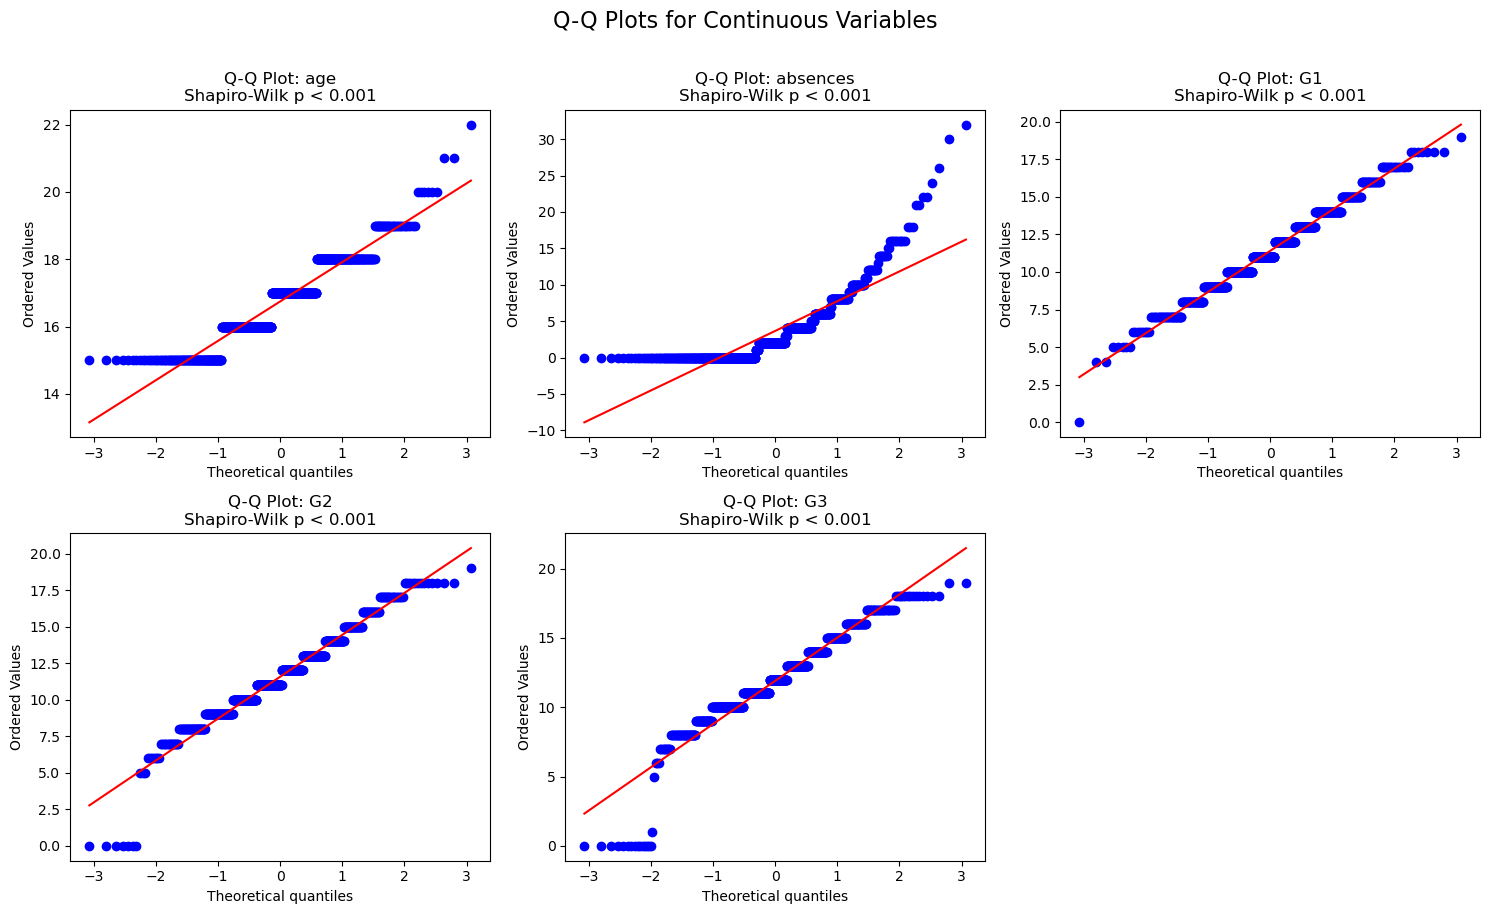

Saved: reports/figures/qq_plots.png


In [6]:
qq_cols = ['age', 'absences', 'G1', 'G2', 'G3']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, qq_cols):
    values = df[col].dropna()
    stats.probplot(values, dist='norm', plot=ax)
    _, p_value = stats.shapiro(values)
    p_label = f'p = {p_value:.2e}' if p_value >= 0.001 else 'p < 0.001'
    ax.set_title(f'Q-Q Plot: {col}\nShapiro-Wilk {p_label}')

for ax in axes[len(qq_cols):]:
    ax.set_visible(False)

fig.suptitle('Q-Q Plots for Continuous Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(figures_dir / 'qq_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/qq_plots.png')

**Findings.** The Q-Q plots show departures from a normal distribution, especially for absences and the discrete grade variables. Where the Shapiro-Wilk test is very small, it is labelled `p < 0.001` rather than as zero. These results support using Spearman correlation for rank-based associations.

## 6. Saved-file check

In [7]:
expected_files = [
    'distribution_plots.png', 'boxplots.png', 'correlation_heatmap.png', 'qq_plots.png',
    'scatter_matrix.html', '3d_scatter.html', 'pair_plot.html'
]
missing = [name for name in expected_files if not (figures_dir / name).exists()]
assert not missing, f'Missing files: {missing}'
for name in expected_files:
    print(f'✓ {name}')
print('All Student C visualization deliverables are saved.')

✓ distribution_plots.png
✓ boxplots.png
✓ correlation_heatmap.png
✓ qq_plots.png
✓ scatter_matrix.html
✓ 3d_scatter.html
✓ pair_plot.html
All Student C visualization deliverables are saved.
